# Examen Aplicado de Machine Learning I

## Dataset: Bike Sharing

- **Fuente:** UCI Machine Learning Repository
- **URL:** https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset
- **Archivo utilizado:** day.csv
- **Número de filas:** 731
- **Número de columnas:** 16
- **Variable objetivo:** `cnt`
- **Tipo de tarea:** Regresión


In [39]:
# Bibliotecas 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
# Cargar el archivo CSV en un DataFrame
df = pd.read_csv("day.csv")

# Mostrar las dimensiones del dataset
df.shape

(731, 16)

In [41]:
# Mostrar el tipo de dato de cada columna
df.dtypes

instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [42]:
# Mostrar información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB


In [43]:
# Mostrar estadísticas descriptivas de las variables numéricas
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [44]:
# Mostrar las primeras 5 filas del dataset
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Interpretación de la inspección inicial

El dataset contiene 731 observaciones diarias y 16 columnas. La variable `dteday` fue cargada como texto, mientras que las variables `temp`, `atemp`, `hum` y `windspeed` son numéricas continuas. Varias variables categóricas, como `season`, `mnth`, `weekday` y `weathersit`, se encuentran representadas mediante códigos numéricos.

Todas las columnas presentan 731 valores no nulos, por lo que inicialmente no se observan datos faltantes. La columna `instant` corresponde a un identificador del registro. Además, se comprobó que `cnt` es la suma de `casual` y `registered`; por esta razón, estas dos variables no deberán utilizarse como predictoras, ya que producirían fuga de información.

## Análisis de valores faltantes

In [45]:
# Calcular la cantidad de valores nulos por columna
cantidad_nulos = df.isnull().sum()

# Calcular el porcentaje de valores nulos por columna
porcentaje_nulos = (cantidad_nulos / len(df)) * 100

# Organizar los resultados en una tabla
resumen_nulos = pd.DataFrame({
    "Cantidad de nulos": cantidad_nulos,
    "Porcentaje de nulos (%)": porcentaje_nulos.round(2)
})

resumen_nulos

,Cantidad de nulos,Porcentaje de nulos (%)
instant,0,0.0
dteday,0,0.0
season,0,0.0
yr,0,0.0
mnth,0,0.0
holiday,0,0.0
weekday,0,0.0
workingday,0,0.0
weathersit,0,0.0
temp,0,0.0


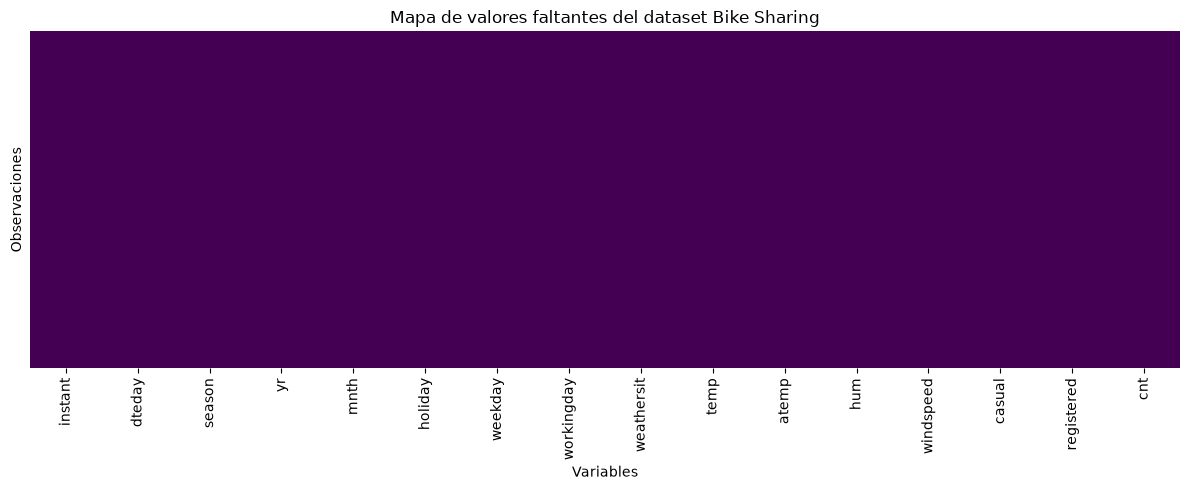

In [46]:
# Crear un mapa de calor de los valores faltantes
plt.figure(figsize=(12, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Mapa de valores faltantes del dataset Bike Sharing")
plt.xlabel("Variables")
plt.ylabel("Observaciones")
plt.tight_layout()

# Guardar el gráfico con la resolución exigida
plt.savefig(
    "figures/heatmap_valores_faltantes.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Interpretación de los valores faltantes

El análisis confirmó que las 16 columnas contienen 731 valores válidos, equivalentes al 100% de las observaciones. Por lo tanto, el porcentaje de valores nulos es 0,0% en todas las variables. El heatmap presenta un color uniforme, lo que confirma visualmente la ausencia de datos faltantes.

Debido a que el dataset está completo, no se eliminarán columnas ni se aplicará imputación en esta etapa. Sin embargo, el pipeline de preprocesamiento incorporará `SimpleImputer`, tal como piden las instrucciones del examen, y será ajustado exclusivamente con los datos de entrenamiento para evitar fuga de información.

## Detección y tratamiento de outliers

In [47]:
# Variables numéricas continuas que serán utilizadas como predictoras
variables_continuas = ["temp", "atemp", "hum", "windspeed"]

# Calcular el primer y tercer cuartil
Q1 = df[variables_continuas].quantile(0.25)
Q3 = df[variables_continuas].quantile(0.75)

# Calcular el rango intercuartílico
IQR = Q3 - Q1

# Definir los límites para detectar posibles outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar los valores que están fuera de los límites
mascara_outliers = (
    (df[variables_continuas] < limite_inferior) |
    (df[variables_continuas] > limite_superior)
)

# Contar y calcular el porcentaje de outliers por variable
cantidad_outliers = mascara_outliers.sum()
porcentaje_outliers = (cantidad_outliers / len(df)) * 100

# Organizar los resultados en una tabla
resumen_outliers = pd.DataFrame({
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "Límite inferior": limite_inferior,
    "Límite superior": limite_superior,
    "Cantidad de outliers": cantidad_outliers,
    "Porcentaje de outliers (%)": porcentaje_outliers
})

resumen_outliers.round(4)

,Q1,Q3,IQR,Límite inferior,Límite superior,Cantidad de outliers,Porcentaje de outliers (%)
temp,0.3371,0.6554,0.3183,-0.1404,1.1329,0,0.0000
atemp,0.3378,0.6086,0.2708,-0.0683,1.0147,0,0.0000
hum,0.5200,0.7302,0.2102,0.2047,1.0455,2,0.2736
windspeed,0.1349,0.2332,0.0983,-0.0124,0.3806,13,1.7784


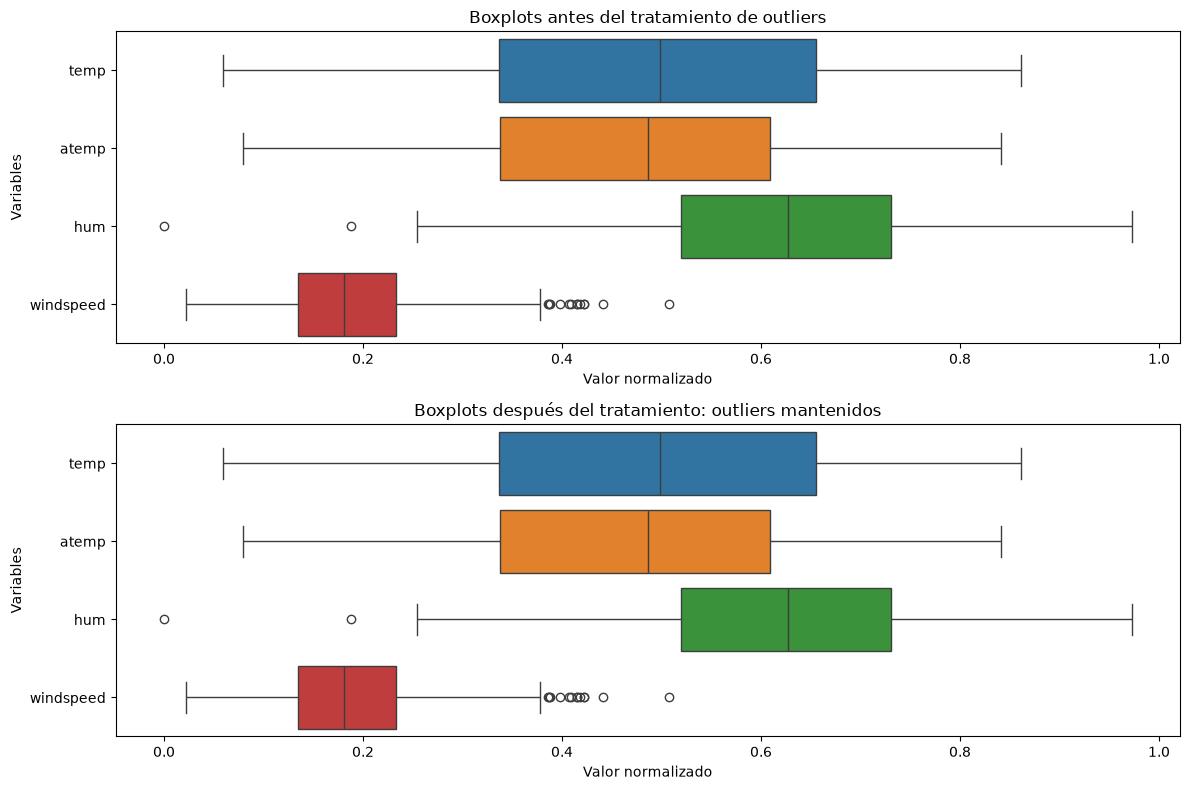

In [48]:
# Mantener los outliers porque corresponden a condiciones meteorológicas posibles
df_tratado = df.copy()

# Crear boxplots antes y después de la decisión de tratamiento
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

sns.boxplot(
    data=df[variables_continuas],
    orient="h",
    ax=axes[0]
)
axes[0].set_title("Boxplots antes del tratamiento de outliers")
axes[0].set_xlabel("Valor normalizado")
axes[0].set_ylabel("Variables")

sns.boxplot(
    data=df_tratado[variables_continuas],
    orient="h",
    ax=axes[1]
)
axes[1].set_title("Boxplots después del tratamiento: outliers mantenidos")
axes[1].set_xlabel("Valor normalizado")
axes[1].set_ylabel("Variables")

plt.tight_layout()

# Guardar el gráfico con la resolución exigida
plt.savefig(
    "figures/boxplots_outliers_antes_despues.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Interpretación y decisión sobre los valores extremos

El método IQR no identificó valores extremos en las variables `temp` y `atemp`. En cambio, detectó 2 valores extremos en `hum`, equivalentes al 0,2736% de las observaciones, y 13 en `windspeed`, correspondientes al 1,7784%.

Se decidió mantener estos valores porque representan condiciones meteorológicas reales que pueden ocurrir en determinados días. Un nivel inusual de humedad o una velocidad elevada del viento no constituye necesariamente un error de registro y podría aportar información relevante para explicar cambios en la demanda de bicicletas. Además, la proporción de valores extremos es baja y no existe evidencia que justifique su eliminación o imputación. 



## Distribución de la variable objetivo

Skewness de cnt: -0.0474


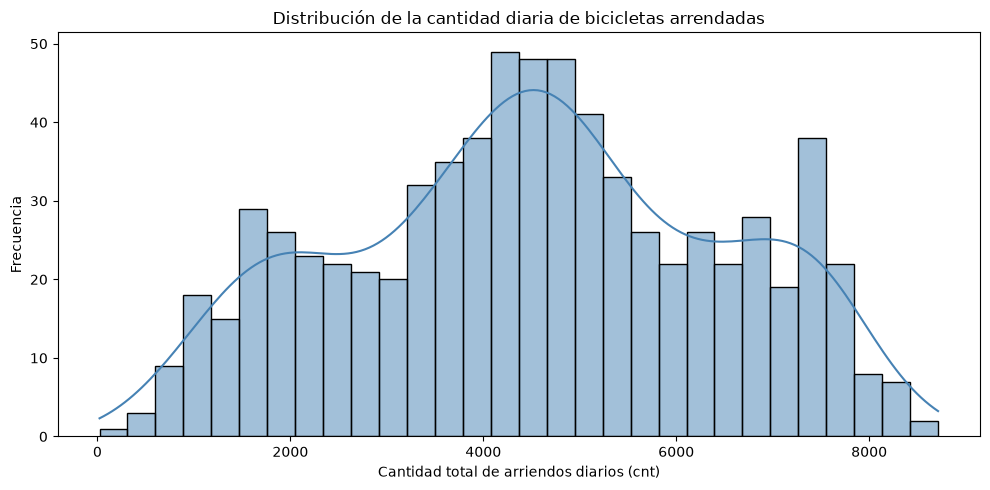

In [49]:
# Calcular la asimetría de la variable objetivo
asimetria_cnt = df["cnt"].skew()

print(f"Skewness de cnt: {asimetria_cnt:.4f}")

# Crear el histograma junto con la curva KDE
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="cnt",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribución de la cantidad diaria de bicicletas arrendadas")
plt.xlabel("Cantidad total de arriendos diarios (cnt)")
plt.ylabel("Frecuencia")
plt.tight_layout()

# Guardar el gráfico con la resolución exigida
plt.savefig(
    "figures/distribucion_variable_objetivo_cnt.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Interpretación de la variable objetivo

La variable objetivo `cnt` presenta un skewness de -0,0474, valor muy cercano a cero. Esto indica que su distribución es aproximadamente simétrica, con una inclinación negativa mínima. Aunque la curva KDE muestra algunas concentraciones en distintos niveles de demanda, no se observa una asimetría pronunciada.

Como el valor de skewness no supera el límite de 1,0 establecido en la guía, no se aplicará una transformación logarítmica. La variable objetivo se mantendrá en su escala original, lo que también facilitará la interpretación posterior de las predicciones y de las métricas de error en términos de cantidad diaria de bicicletas arrendadas.

## Análisis exploratorio y correlaciones

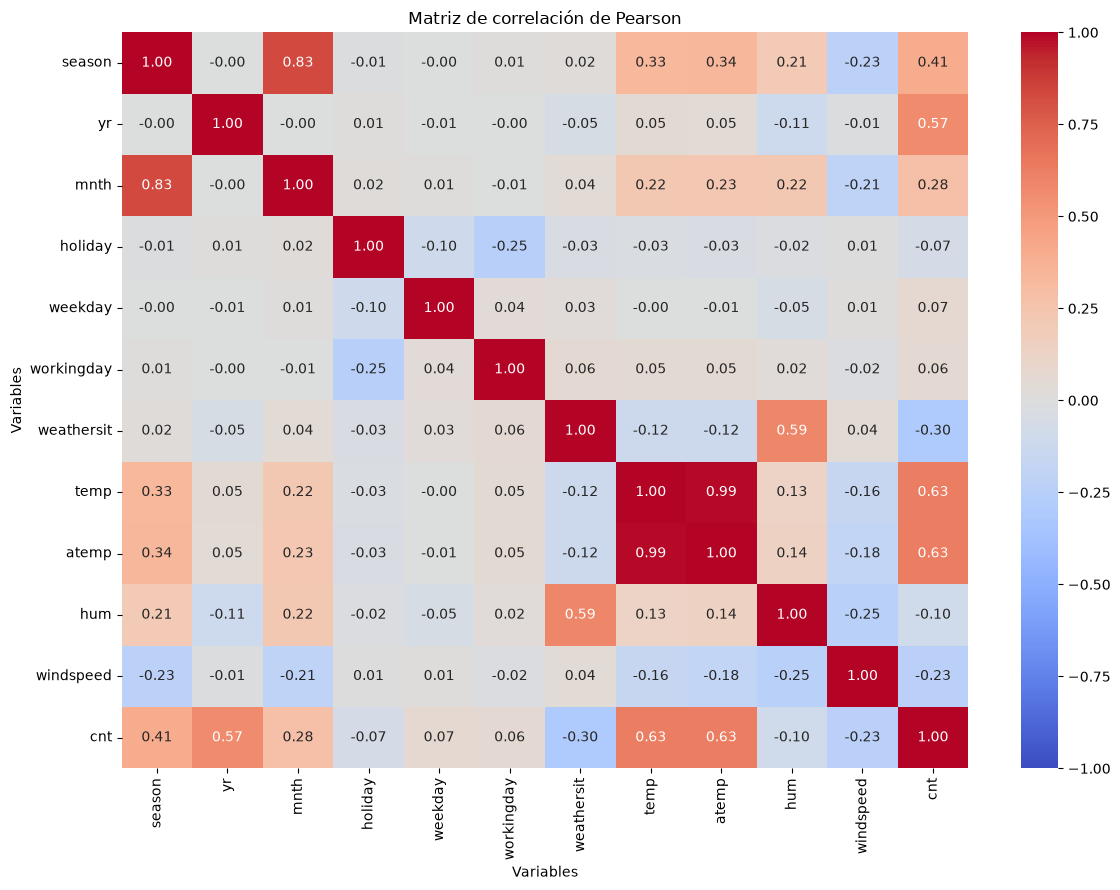

In [50]:
# Crear un DataFrame para el EDA sin identificadores ni variables con fuga de información
df_eda = df.drop(
    columns=["instant", "dteday", "casual", "registered"]
)

# Calcular la matriz de correlación de Pearson
matriz_correlacion = df_eda.corr(method="pearson")

# Crear el heatmap de correlaciones
plt.figure(figsize=(12, 9))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlación de Pearson")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.tight_layout()

# Guardar el gráfico con la resolución exigida
plt.savefig(
    "figures/heatmap_correlacion_pearson.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [51]:
# Obtener las correlaciones de todas las variables con la variable objetivo
correlaciones_objetivo = matriz_correlacion["cnt"].drop("cnt")

# Seleccionar las 5 correlaciones más altas en valor absoluto
indices_top5 = correlaciones_objetivo.abs().nlargest(5).index

# Crear una tabla con la correlación original y su valor absoluto
top5_correlaciones = pd.DataFrame({
    "Correlación con cnt": correlaciones_objetivo.loc[indices_top5],
    "Valor absoluto": correlaciones_objetivo.loc[indices_top5].abs()
})

top5_correlaciones.round(4)

,Correlación con cnt,Valor absoluto
atemp,0.6311,0.6311
temp,0.6275,0.6275
yr,0.5667,0.5667
season,0.4061,0.4061
weathersit,-0.2974,0.2974


In [52]:
# Crear la matriz de correlación solamente entre predictores
correlacion_predictores = df_eda.drop(columns="cnt").corr(method="pearson")

# Buscar pares de predictores con correlación absoluta superior a 0.85
pares_multicolineales = []

columnas_predictoras = correlacion_predictores.columns

for i in range(len(columnas_predictoras)):
    for j in range(i + 1, len(columnas_predictoras)):
        variable_1 = columnas_predictoras[i]
        variable_2 = columnas_predictoras[j]
        correlacion = correlacion_predictores.loc[variable_1, variable_2]

        if abs(correlacion) > 0.85:
            pares_multicolineales.append({
                "Variable 1": variable_1,
                "Variable 2": variable_2,
                "Correlación": correlacion
            })

tabla_multicolinealidad = pd.DataFrame(pares_multicolineales)

tabla_multicolinealidad.round(4)

,Variable 1,Variable 2,Correlación
0,temp,atemp,0.9917


### Interpretación de correlaciones y multicolinealidad

Las variables con mayor correlación absoluta con `cnt` fueron `atemp` (0,6311), `temp` (0,6275), `yr` (0,5667), `season` (0,4061) y `weathersit` (-0,2974). Las correlaciones positivas de `temp` y `atemp` indican que los días con temperaturas más elevadas tienden a presentar una mayor cantidad de arriendos. La correlación positiva de `yr` sugiere que la demanda fue mayor en el segundo año registrado.

Por otra parte, `weathersit` presenta una correlación negativa con `cnt`. Como sus valores aumentan cuando las condiciones meteorológicas empeoran, este resultado indica que el clima desfavorable se relaciona con una menor demanda de bicicletas. La correlación de `season` debe interpretarse con cautela, porque sus números representan categorías y no una escala cuantitativa continua.

El análisis de multicolinealidad identificó una correlación de 0,9917 entre `temp` y `atemp`, superior al límite de 0,85. Esto se explica porque ambas variables representan mediciones relacionadas con la temperatura. Se mantendrán inicialmente ambas variables, ya que solicitan reportar la multicolinealidad. Esta relación deberá considerarse posteriormente al interpretar los coeficientes y la importancia de variables.

### Relación de las variables más correlacionadas con la demanda

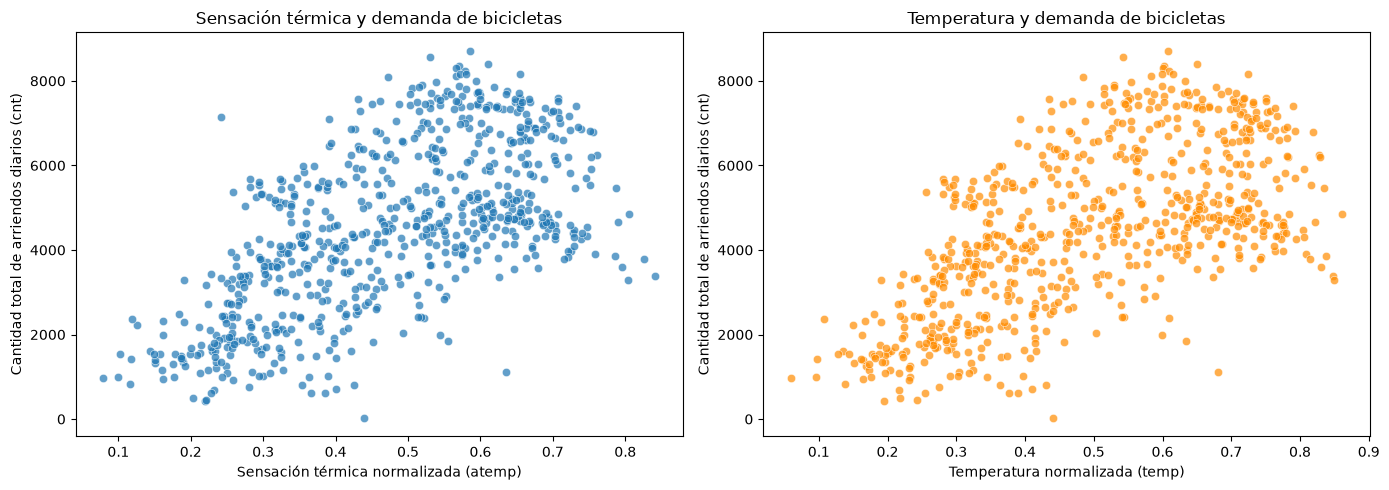

In [53]:
# Crear scatterplots de las dos variables más correlacionadas con cnt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df_eda,
    x="atemp",
    y="cnt",
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title("Sensación térmica y demanda de bicicletas")
axes[0].set_xlabel("Sensación térmica normalizada (atemp)")
axes[0].set_ylabel("Cantidad total de arriendos diarios (cnt)")

sns.scatterplot(
    data=df_eda,
    x="temp",
    y="cnt",
    alpha=0.7,
    color="darkorange",
    ax=axes[1]
)
axes[1].set_title("Temperatura y demanda de bicicletas")
axes[1].set_xlabel("Temperatura normalizada (temp)")
axes[1].set_ylabel("Cantidad total de arriendos diarios (cnt)")

plt.tight_layout()

# Guardar la figura con la resolución exigida
plt.savefig(
    "figures/scatter_variables_mas_correlacionadas.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Interpretación de los scatterplots

Los scatterplots muestran una relación positiva entre la demanda diaria de bicicletas y las variables `temp` y `atemp`. En general, los días con temperaturas y sensaciones térmicas más elevadas presentan una mayor cantidad de arriendos, lo que coincide con las correlaciones positivas de 0,6275 y 0,6311, respectivamente.

Sin embargo, los puntos presentan una dispersión considerable. Para valores similares de temperatura se observan cantidades diferentes de arriendos, lo que indica que la demanda no depende exclusivamente de esta condición meteorológica. Variables como el año, la estación, el tipo de día y las condiciones climáticas también podrían contribuir a explicar estas diferencias.

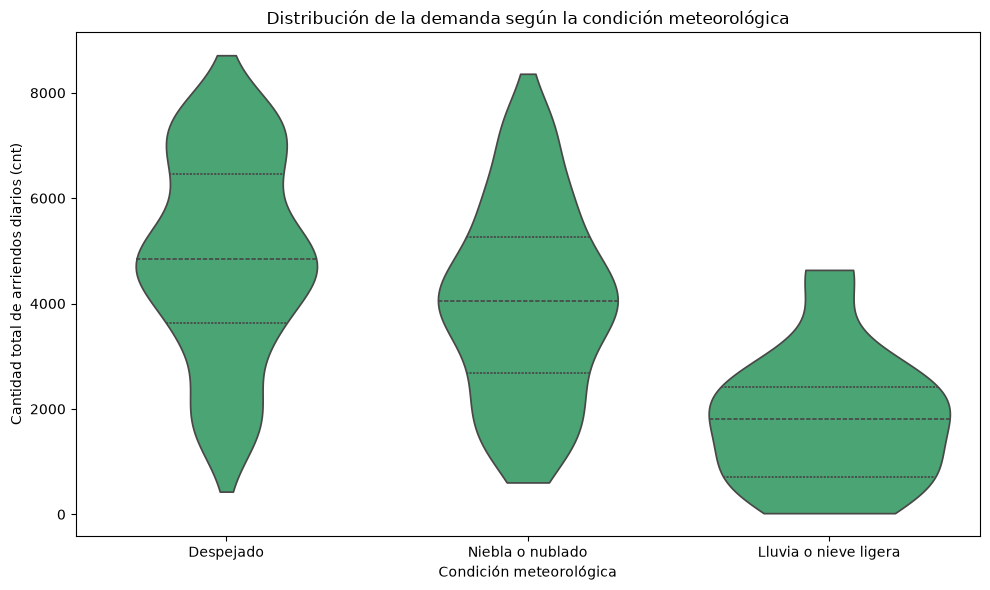

In [54]:
# Comparar la distribución de la demanda según la condición meteorológica
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_eda,
    x="weathersit",
    y="cnt",
    inner="quartile",
    cut=0,
    color="mediumseagreen"
)

plt.title("Distribución de la demanda según la condición meteorológica")
plt.xlabel("Condición meteorológica")
plt.ylabel("Cantidad total de arriendos diarios (cnt)")

plt.xticks(
    ticks=[0, 1, 2],
    labels=[
        "Despejado",
        "Niebla o nublado",
        "Lluvia o nieve ligera"
    ]
)

plt.tight_layout()

# Guardar la figura con la resolución exigida
plt.savefig(
    "figures/violin_demanda_condicion_meteorologica.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Interpretación de la demanda según la condición meteorológica

El violin plot muestra diferencias en la distribución de la demanda según las condiciones meteorológicas. Los días despejados presentan la mediana más alta y una mayor concentración de observaciones en niveles elevados de arriendos. En los días con niebla o nubosidad, la mediana de `cnt` disminuye y la distribución se desplaza hacia valores intermedios.

Los días con lluvia o nieve ligera presentan la demanda más baja, con una mayor concentración de observaciones bajo los 3.000 arriendos diarios. Este patrón coincide con la correlación negativa de -0,2974 encontrada entre `weathersit` y `cnt`: a medida que las condiciones meteorológicas se vuelven más adversas, la cantidad de bicicletas arrendadas tiende a disminuir.

## División de los datos en entrenamiento y prueba

La variable objetivo será `cnt`. Se excluyen `instant` por corresponder únicamente a un identificador, y `casual` junto con `registered` porque su suma determina directamente el valor de `cnt`, lo que produciría fuga de información.

También se excluye `dteday`, debido a que cada fecha es prácticamente única y su información temporal ya está representada mediante las variables `yr`, `mnth`, `weekday` y `season`. Después de estas exclusiones quedan 11 variables predictoras.

In [55]:
# Importar la función para dividir los datos
from sklearn.model_selection import train_test_split

# Definir las variables predictoras
X = df.drop(
    columns=["instant", "dteday", "casual", "registered", "cnt"]
)

# Definir la variable objetivo
y = df["cnt"]

# Dividir los datos antes de cualquier transformación
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Mostrar las dimensiones de cada partición
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_train: (584, 11)
Dimensiones de X_test: (147, 11)
Dimensiones de y_train: (584,)
Dimensiones de y_test: (147,)


## Pipeline de preprocesamiento

In [56]:
# Importar las herramientas de preprocesamiento
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)
from sklearn import set_config

# Separar las columnas según su tipo
variables_numericas = [
    "temp",
    "atemp",
    "hum",
    "windspeed"
]

variables_nominales = [
    "season",
    "yr",
    "mnth",
    "holiday",
    "weekday",
    "workingday"
]

variables_ordinales = [
    "weathersit"
]

# Pipeline para variables numéricas
pipeline_numerico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler())
])

# Pipeline para variables nominales
pipeline_nominal = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

# Pipeline para la variable ordinal
pipeline_ordinal = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    (
        "ordinal",
        OrdinalEncoder(
            categories=[[1, 2, 3, 4]],
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    )
])

# Combinar los tres pipelines
preprocesador = ColumnTransformer(
    transformers=[
        ("numericas", pipeline_numerico, variables_numericas),
        ("nominales", pipeline_nominal, variables_nominales),
        ("ordinales", pipeline_ordinal, variables_ordinales)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Mostrar visualmente la estructura del preprocesador
set_config(display="diagram")

preprocesador

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('nominales', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per

In [57]:
# Configurar la salida como DataFrame para conservar los nombres de las variables
preprocesador.set_output(transform="pandas")

# Ajustar y transformar únicamente los datos de entrenamiento
X_train_prep = preprocesador.fit_transform(X_train)

# Aplicar a test las transformaciones aprendidas con entrenamiento
X_test_prep = preprocesador.transform(X_test)

# Mostrar las dimensiones después del preprocesamiento
print("Dimensiones de X_train preprocesado:", X_train_prep.shape)
print("Dimensiones de X_test preprocesado:", X_test_prep.shape)

# Mostrar las primeras 5 filas del conjunto de entrenamiento preprocesado
X_train_prep.head()

Dimensiones de X_train preprocesado: (584, 34)
Dimensiones de X_test preprocesado: (147, 34)


,temp,atemp,hum,windspeed,season_1,season_2,season_3,season_4,yr_0,yr_1,...,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_0,workingday_1,weathersit
682,-0.864610,-0.961525,0.223424,1.957045,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
250,0.737288,0.475581,2.171018,0.026719,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0
336,-1.108087,-1.039659,-0.128574,-1.226972,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
260,0.040404,0.074269,0.449288,-0.157718,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
543,1.087829,1.004466,-1.909102,1.048487,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


### Resultado del preprocesamiento

El preprocesador fue ajustado exclusivamente con `X_train` mediante `fit_transform()`, mientras que sobre `X_test` solo se aplicó `transform()`. De esta forma, las medianas, categorías, medias y desviaciones fueron aprendidas sin utilizar información del conjunto de prueba.

Después del preprocesamiento, ambos conjuntos pasaron de 11 a 34 columnas debido a la codificación One-Hot de las variables nominales. Las variables continuas fueron estandarizadas, las nominales se transformaron en columnas binarias y `weathersit` conservó su orden mediante codificación ordinal.

## Análisis de Componentes Principales (PCA)

In [58]:
# Importar PCA
from sklearn.decomposition import PCA

# Ajustar PCA solamente sobre el conjunto de entrenamiento preprocesado
pca_completo = PCA()

X_train_pca_completo = pca_completo.fit_transform(X_train_prep)

# Obtener la varianza explicada y la varianza acumulada
varianza_explicada = pca_completo.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Crear la tabla de resultados
tabla_varianza_pca = pd.DataFrame({
    "Componente": np.arange(1, len(varianza_explicada) + 1),
    "Varianza explicada": varianza_explicada,
    "Varianza acumulada": varianza_acumulada
})

tabla_varianza_pca.round(4)

,Componente,Varianza explicada,Varianza acumulada
0,1,0.2995,0.2995
1,2,0.1601,0.4597
2,3,0.1093,0.5690
3,4,0.0739,0.6429
4,5,0.0629,0.7057
5,6,0.0413,0.7470
6,7,0.0379,0.7849
7,8,0.0213,0.8062
8,9,0.0194,0.8256
9,10,0.0184,0.8440


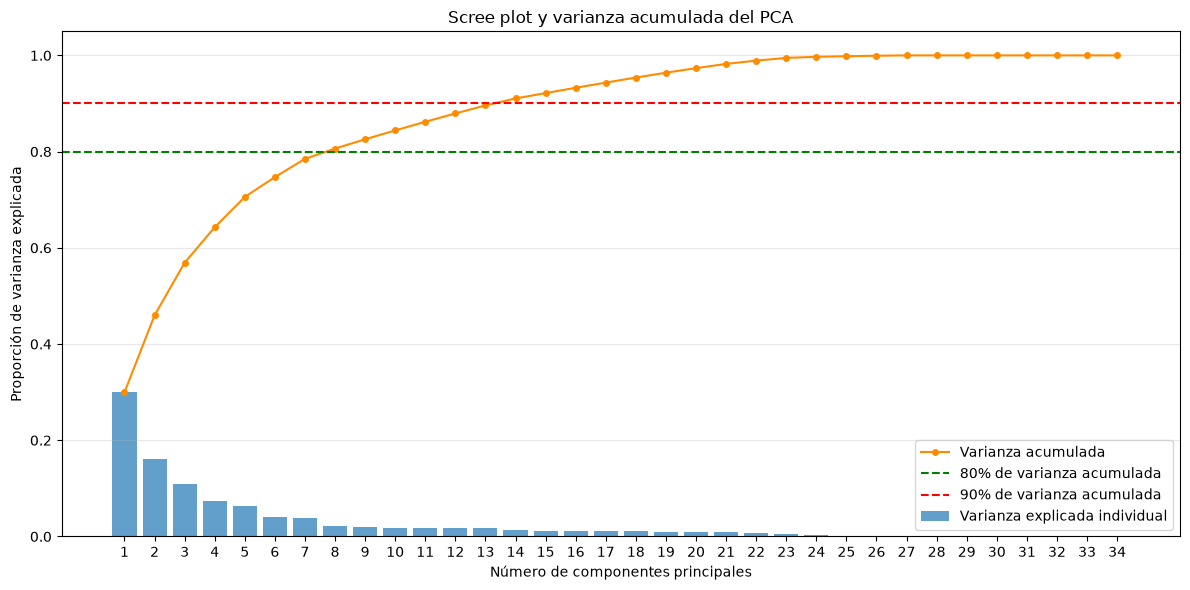

In [59]:
# Crear el número de cada componente
componentes = np.arange(1, len(varianza_explicada) + 1)

# Crear el scree plot
plt.figure(figsize=(12, 6))

plt.bar(
    componentes,
    varianza_explicada,
    alpha=0.7,
    label="Varianza explicada individual"
)

plt.plot(
    componentes,
    varianza_acumulada,
    color="darkorange",
    marker="o",
    markersize=4,
    label="Varianza acumulada"
)

# Límites solicitados por la guía
plt.axhline(
    y=0.80,
    color="green",
    linestyle="--",
    label="80% de varianza acumulada"
)

plt.axhline(
    y=0.90,
    color="red",
    linestyle="--",
    label="90% de varianza acumulada"
)

plt.title("Scree plot y varianza acumulada del PCA")
plt.xlabel("Número de componentes principales")
plt.ylabel("Proporción de varianza explicada")
plt.xticks(componentes)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

# Guardar el gráfico con la resolución exigida
plt.savefig(
    "figures/scree_plot_pca.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Selección del número de componentes

Se seleccionaron 8 componentes principales, que explican en conjunto el 80,62% de la varianza de los datos preprocesados. Esta cantidad corresponde al mínimo número de componentes que supera el umbral del 80% establecido en la guía y se mantiene dentro del intervalo solicitado de 80% a 90%.

La elección permite reducir las 34 variables generadas durante el preprocesamiento a 8 componentes, conservando la mayor parte de la información y disminuyendo la dimensionalidad. Agregar más componentes aumentaría progresivamente la varianza acumulada, pero con aportes individuales cada vez menores.

In [60]:
# Número de componentes seleccionado
n_componentes = 8

# Crear el PCA definitivo
pca_seleccionado = PCA(
    n_components=n_componentes,
    random_state=42
)

# Ajustar PCA solamente con entrenamiento
X_train_pca = pca_seleccionado.fit_transform(X_train_prep)

# Aplicar a test la transformación aprendida con entrenamiento
X_test_pca = pca_seleccionado.transform(X_test_prep)

# Crear nombres para los componentes
nombres_componentes = [
    f"PC{i}" for i in range(1, n_componentes + 1)
]

# Convertir el resultado de entrenamiento en un DataFrame
df_pca_train = pd.DataFrame(
    X_train_pca,
    columns=nombres_componentes,
    index=X_train.index
)

print("Dimensiones de X_train con PCA:", X_train_pca.shape)
print("Dimensiones de X_test con PCA:", X_test_pca.shape)

Dimensiones de X_train con PCA: (584, 8)
Dimensiones de X_test con PCA: (147, 8)


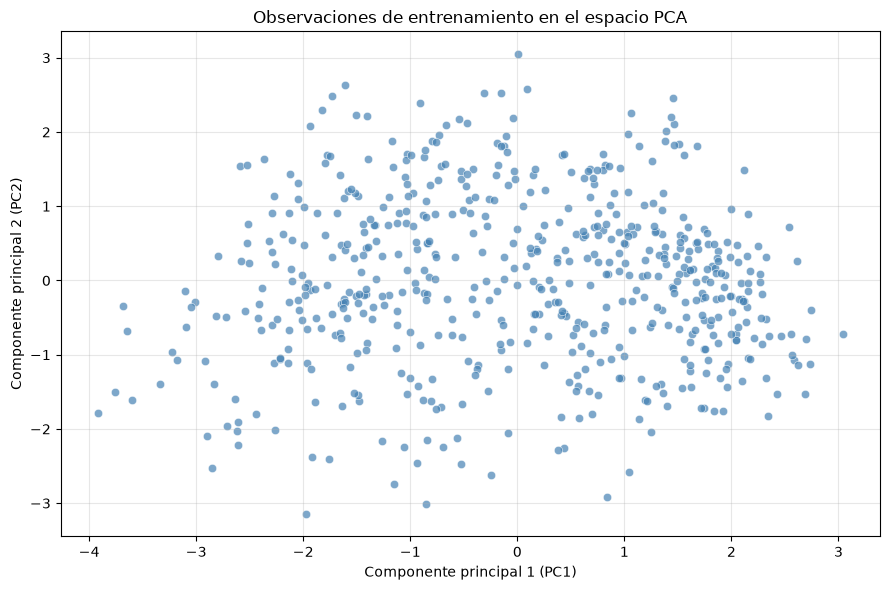

In [61]:
# Visualizar las observaciones en el espacio PC1 versus PC2
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_pca_train,
    x="PC1",
    y="PC2",
    alpha=0.7,
    color="steelblue"
)

plt.title("Observaciones de entrenamiento en el espacio PCA")
plt.xlabel("Componente principal 1 (PC1)")
plt.ylabel("Componente principal 2 (PC2)")
plt.grid(alpha=0.3)
plt.tight_layout()

# Guardar el gráfico con la resolución exigida
plt.savefig(
    "figures/pca_pc1_vs_pc2.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Interpretación del espacio PCA

El gráfico PC1 versus PC2 muestra una distribución continua de las observaciones, sin grupos completamente separados a simple vista. La mayoría de los días se concentra en la zona central, mientras que algunos presentan posiciones más alejadas debido a combinaciones particulares de temperatura, humedad, viento, estación y condición meteorológica. Por esta razón, la existencia y cantidad adecuada de clusters no debe decidirse únicamente mediante inspección visual, sino que será evaluada posteriormente con el método del codo y el Silhouette Score.

In [62]:
# Crear la tabla completa de loadings
tabla_loadings = pd.DataFrame(
    pca_seleccionado.components_.T,
    index=X_train_prep.columns,
    columns=nombres_componentes
)

# Identificar las 5 variables con mayor contribución absoluta a PC1
indices_pc1 = tabla_loadings["PC1"].abs().nlargest(5).index

top5_loadings_pc1 = pd.DataFrame({
    "Variable": indices_pc1,
    "Loading PC1": tabla_loadings.loc[indices_pc1, "PC1"].values,
    "Valor absoluto": tabla_loadings.loc[indices_pc1, "PC1"].abs().values
})

# Identificar las 5 variables con mayor contribución absoluta a PC2
indices_pc2 = tabla_loadings["PC2"].abs().nlargest(5).index

top5_loadings_pc2 = pd.DataFrame({
    "Variable": indices_pc2,
    "Loading PC2": tabla_loadings.loc[indices_pc2, "PC2"].values,
    "Valor absoluto": tabla_loadings.loc[indices_pc2, "PC2"].abs().values
})

print("Cinco variables con mayor contribución a PC1:")
display(top5_loadings_pc1.round(4))

print("Cinco variables con mayor contribución a PC2:")
display(top5_loadings_pc2.round(4))

Cinco variables con mayor contribución a PC1:


,Variable,Loading PC1,Valor absoluto
0,atemp,0.6390,0.6390
1,temp,0.6366,0.6366
2,windspeed,-0.2189,0.2189
3,season_3,0.1913,0.1913
4,season_1,-0.1868,0.1868


Cinco variables con mayor contribución a PC2:


,Variable,Loading PC2,Valor absoluto
0,hum,0.7563,0.7563
1,windspeed,-0.5035,0.5035
2,weathersit,0.2717,0.2717
3,temp,-0.1758,0.1758
4,atemp,-0.1551,0.1551


### Interpretación de los *loadings* de PC1 y PC2

En el primer componente principal (**PC1**), las variables con mayor contribución fueron `atemp` (0,6390) y `temp` (0,6366). Ambas presentan *loadings* positivos y de magnitud similar, lo que indica que PC1 representa principalmente una dimensión asociada con la temperatura y la sensación térmica.

La variable `windspeed` presentó una contribución negativa de -0,2189. Esto significa que, dentro de este componente, los valores altos de velocidad del viento tienden a ubicarse en la dirección opuesta a los valores altos de temperatura. Las variables `season_3` y `season_1` también aparecen en sentidos contrarios, mostrando que las diferencias estacionales participan en la construcción de PC1.

En el segundo componente principal (**PC2**), la mayor contribución correspondió a `hum` (0,7563), seguida por `windspeed` (-0,5035) y `weathersit` (0,2717). Por lo tanto, PC2 representa principalmente un contraste entre la humedad, la velocidad del viento y la condición meteorológica. Las variables `temp` y `atemp` también contribuyen negativamente, aunque con menor intensidad.

El signo positivo o negativo de un *loading* indica la dirección de la relación dentro del componente, mientras que su valor absoluto representa la importancia de la variable. En conjunto, PC1 resume principalmente las condiciones térmicas y estacionales, mientras que PC2 diferencia perfiles meteorológicos asociados con la humedad, el viento y el estado general del clima.


## Selección del número de clusters con K-Means

Se evaluarán distintas soluciones de K-Means utilizando valores de `K` entre 2 y 10. Para seleccionar el número adecuado de clusters se analizarán la inercia mediante el método del codo y el Silhouette Score.

In [63]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Lista en la que guardaremos los resultados de cada valor de K
resultados_kmeans = []

# Evaluar soluciones desde 2 hasta 10 clusters
for k in range(2, 11):

    # Crear y entrenar el modelo K-Means
    modelo_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Asignar un cluster a cada observación de entrenamiento
    etiquetas = modelo_kmeans.fit_predict(X_train_pca)

    # Guardar la inercia y el Silhouette Score
    resultados_kmeans.append({
        "K": k,
        "Inercia": modelo_kmeans.inertia_,
        "Silhouette Score": silhouette_score(
            X_train_pca,
            etiquetas
        )
    })

# Convertir los resultados en una tabla
tabla_kmeans = pd.DataFrame(resultados_kmeans)

# Mostrar la tabla con cuatro decimales
tabla_kmeans.round(4)

,K,Inercia,Silhouette Score
0,2,2654.2488,0.2498
1,3,2298.1407,0.2097
2,4,2095.6172,0.1671
3,5,1935.9793,0.1724
4,6,1808.3007,0.1728
5,7,1699.1032,0.1714
6,8,1614.9382,0.1692
7,9,1538.2140,0.1657
8,10,1486.4747,0.1749


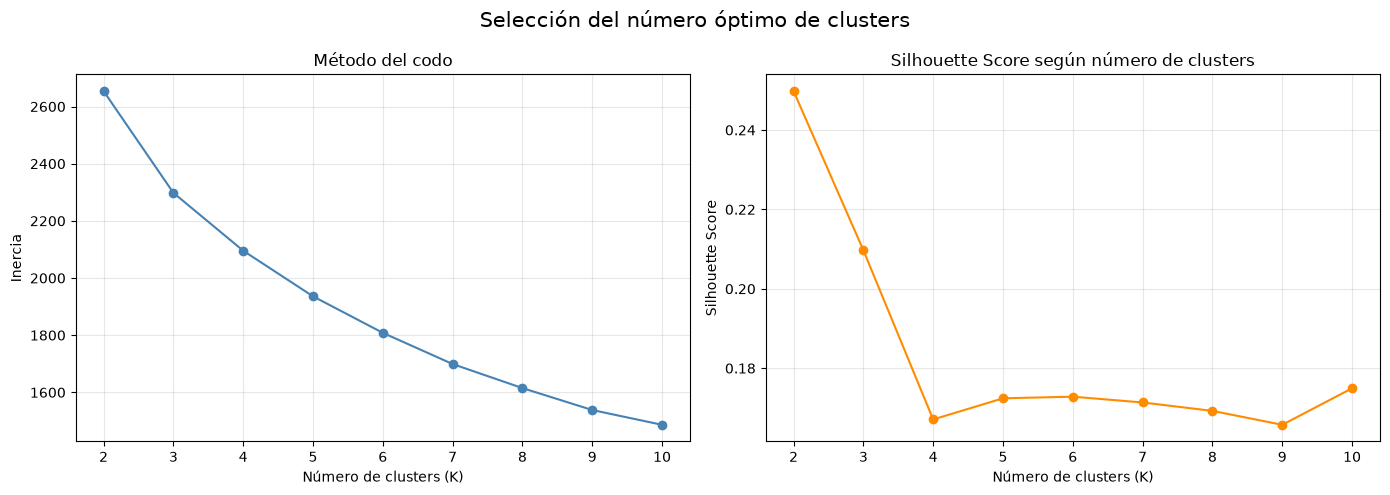

In [64]:
# Crear una figura con dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: método del codo
axes[0].plot(
    tabla_kmeans["K"],
    tabla_kmeans["Inercia"],
    marker="o",
    color="steelblue"
)

axes[0].set_title("Método del codo")
axes[0].set_xlabel("Número de clusters (K)")
axes[0].set_ylabel("Inercia")
axes[0].set_xticks(tabla_kmeans["K"])
axes[0].grid(alpha=0.3)

# Gráfico 2: Silhouette Score
axes[1].plot(
    tabla_kmeans["K"],
    tabla_kmeans["Silhouette Score"],
    marker="o",
    color="darkorange"
)

axes[1].set_title("Silhouette Score según número de clusters")
axes[1].set_xlabel("Número de clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(tabla_kmeans["K"])
axes[1].grid(alpha=0.3)

# Título general
fig.suptitle(
    "Selección del número óptimo de clusters",
    fontsize=15
)

plt.tight_layout()

# Guardar la figura
plt.savefig(
    "figures/seleccion_k_kmeans.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Selección del número óptimo de clusters

El método del codo muestra una disminución continua de la inercia a medida que aumenta el número de clusters. La reducción más pronunciada ocurre en los primeros valores de `K`, pero no se observa un codo completamente definido que justifique claramente una solución con muchos grupos.

El Silhouette Score alcanza su valor máximo con `K = 2`, obteniendo un resultado de 0,2498. Al utilizar tres o más clusters, esta métrica disminuye y no vuelve a superar el valor alcanzado con dos grupos.

Por lo tanto, se seleccionó **K = 2** como el número óptimo de clusters. Esta elección se fundamenta principalmente en que presenta el mayor Silhouette Score y proporciona la solución más simple entre las alternativas evaluadas.

Sin embargo, el valor máximo de Silhouette es relativamente bajo, por lo que los clusters no presentan una separación fuerte. Este resultado coincide con el gráfico de PC1 y PC2, donde se observó una distribución continua de los datos. En consecuencia, los clusters deben interpretarse como perfiles generales de días con características similares y no como grupos completamente aislados.


In [65]:
# Número de clusters seleccionado
k_optimo = 2

# Crear y entrenar el modelo K-Means definitivo
kmeans_final = KMeans(
    n_clusters=k_optimo,
    random_state=42,
    n_init=10
)

# Asignar un cluster a cada observación de entrenamiento
clusters_train = kmeans_final.fit_predict(X_train_pca)

# Crear una copia del DataFrame PCA
df_pca_clusters = df_pca_train.copy()

# Incorporar el cluster asignado
df_pca_clusters["cluster"] = clusters_train

# Mostrar la cantidad de observaciones por cluster
print("Cantidad de observaciones por cluster:")
print(df_pca_clusters["cluster"].value_counts().sort_index())

Cantidad de observaciones por cluster:
cluster
0    301
1    283
Name: count, dtype: int64


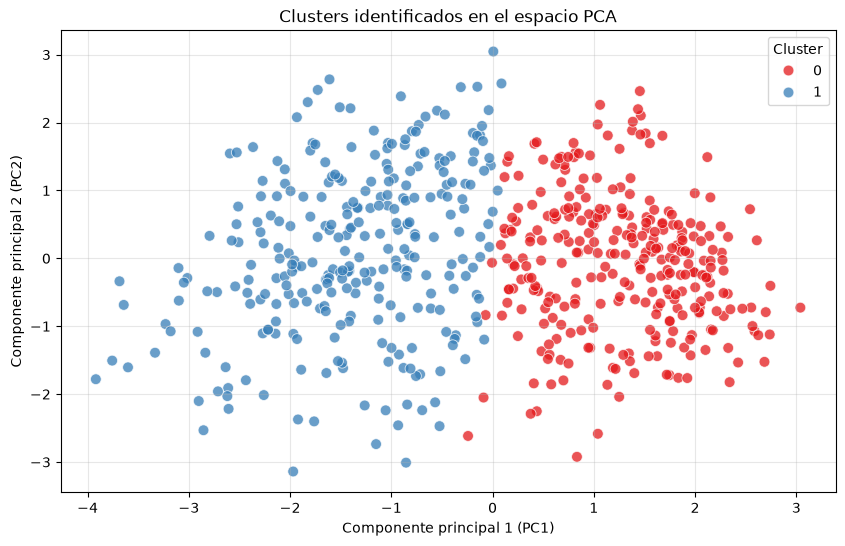

In [66]:
# Visualizar los clusters utilizando las dos primeras componentes
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_pca_clusters,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1",
    s=60,
    alpha=0.75
)

plt.title("Clusters identificados en el espacio PCA")
plt.xlabel("Componente principal 1 (PC1)")
plt.ylabel("Componente principal 2 (PC2)")
plt.legend(title="Cluster")
plt.grid(alpha=0.3)

# Guardar la figura
plt.savefig(
    "figures/clusters_kmeans_espacio_pca.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Interpretación de los clusters en el espacio PCA

K-Means dividió las 584 observaciones de entrenamiento en dos grupos relativamente equilibrados. El cluster 0 contiene 301 observaciones, mientras que el cluster 1 contiene 283, por lo que no existe un grupo excesivamente pequeño.

La separación entre los clusters ocurre principalmente a lo largo del primer componente principal (PC1). El cluster 0 se concentra mayoritariamente en los valores positivos de PC1, mientras que el cluster 1 se ubica principalmente en sus valores negativos. En cambio, ambos grupos presentan una dispersión considerable sobre PC2.

Considerando los *loadings* calculados anteriormente, PC1 está determinado principalmente por `temp` y `atemp`. Por ello, la separación observada sugiere inicialmente que los clusters podrían representar días con diferentes condiciones térmicas. Sin embargo, esta interpretación debe confirmarse mediante el cálculo de las características promedio de cada grupo.

Aunque visualmente existe una separación apreciable, también se observa una zona de superposición cerca del centro del gráfico. Esto concuerda con el Silhouette Score relativamente bajo y confirma que los clusters representan perfiles generales, pero no grupos completamente aislados.


## Caracterización e interpretación de los clusters

Para comprender las características de los grupos obtenidos, se calculará el promedio de cada variable predictora y de la variable objetivo `cnt` dentro de cada cluster.

In [67]:
# Crear una copia de los datos originales de entrenamiento
perfil_clusters = X_train.copy()

# Incorporar la variable objetivo
perfil_clusters["cnt"] = y_train

# Incorporar el cluster asignado por K-Means
perfil_clusters["cluster"] = clusters_train

# Calcular el promedio de cada variable por cluster
medias_por_cluster = perfil_clusters.groupby("cluster").mean()

# Mostrar las variables como filas para facilitar la comparación
medias_por_cluster.T.round(4)

cluster,0,1
season,2.7575,2.2261
yr,0.5183,0.5159
mnth,7.0133,5.8869
holiday,0.0166,0.0353
weekday,3.0000,2.9647
workingday,0.7176,0.6184
weathersit,1.3688,1.4382
temp,0.6522,0.3384
atemp,0.6116,0.3370
hum,0.6559,0.6049


### Interpretación del perfil de los clusters

El **cluster 0** presenta valores promedio considerablemente mayores de temperatura (`temp = 0,6522`) y sensación térmica (`atemp = 0,6116`) que el cluster 1. Además, registra una velocidad del viento promedio menor (`windspeed = 0,1734`) y un valor ligeramente más favorable de condición meteorológica (`weathersit = 1,3688`). Estas características permiten describirlo como un grupo de días relativamente cálidos y con condiciones favorables para utilizar bicicletas.

La demanda promedio del cluster 0 fue de aproximadamente **5.603 arriendos diarios**, frente a **3.453 arriendos diarios** en el cluster 1. Esto representa una diferencia aproximada de 2.150 arriendos diarios y confirma que las condiciones representadas por el cluster 0 se relacionan con una mayor demanda.

Por el contrario, el **cluster 1** presenta temperaturas considerablemente menores (`temp = 0,3384` y `atemp = 0,3370`), una velocidad del viento ligeramente mayor (`windspeed = 0,2091`) y una demanda promedio más baja. Por ello, puede interpretarse como un perfil de días más fríos y menos favorables para el uso de bicicletas.

El cluster 0 también posee una mayor proporción de días laborables, con un promedio de `workingday = 0,7176`, frente a `0,6184` en el cluster 1. La variable `yr` presenta valores prácticamente iguales en ambos grupos, indicando que la separación no se explica simplemente por el año de observación.

Los promedios de `season`, `mnth` y `weekday` deben interpretarse con cautela, porque son códigos de categorías y no medidas continuas. Aun así, los valores de `season` y `mnth` sugieren que el cluster 0 incluye con mayor frecuencia periodos más avanzados y cálidos del año.

En conclusión, K-Means identificó dos perfiles generales: un **cluster 0 de días cálidos y de demanda alta** y un **cluster 1 de días más fríos y de demanda baja**. Estas relaciones describen asociaciones observadas en los datos y no necesariamente efectos causales.


## Modelos supervisados de regresión

Se entrenarán dos modelos para predecir la cantidad total de arriendos diarios (`cnt`):

1. Regresión Ridge como modelo lineal penalizado.
2. Random Forest como modelo basado en árboles.

Los modelos se entrenarán utilizando los datos preprocesados. El conjunto de prueba se reservará exclusivamente para la evaluación final.

In [68]:
import time

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Valores de alpha exigidos 
parametros_ridge = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

# Crear la búsqueda mediante validación cruzada
busqueda_ridge = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid=parametros_ridge,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Registrar el tiempo inicial
inicio_ridge = time.time()

# Entrenar y evaluar cada valor de alpha mediante validación cruzada
busqueda_ridge.fit(X_train_prep, y_train)

# Calcular el tiempo total de búsqueda
tiempo_ridge = time.time() - inicio_ridge

# Recuperar el mejor modelo
mejor_ridge = busqueda_ridge.best_estimator_

print("Mejor valor de alpha:", busqueda_ridge.best_params_)
print(
    "Mejor RMSE de validación cruzada:",
    round(-busqueda_ridge.best_score_, 4)
)
print(
    "Tiempo de búsqueda con validación cruzada:",
    round(tiempo_ridge, 4),
    "segundos"
)

Mejor valor de alpha: {'alpha': 10}
Mejor RMSE de validación cruzada: 802.8207
Tiempo de búsqueda con validación cruzada: 6.7642 segundos


### Ajuste del modelo Ridge

La validación cruzada seleccionó `alpha = 10` como el mejor nivel de penalización para la regresión Ridge. Este valor produjo un RMSE promedio de validación cruzada de 802,8207 arriendos diarios.

La selección de un valor de `alpha` distinto de cero indica que la penalización contribuye a controlar la magnitud de los coeficientes del modelo. Esto resulta especialmente pertinente debido a la alta relación existente entre variables como `temp` y `atemp`.

El tiempo total necesario para evaluar los valores de `alpha` mediante validación cruzada se presenta en la salida de la celda anterior. Este valor puede variar según las características y la carga de trabajo del computador utilizado.

In [69]:
from sklearn.ensemble import RandomForestRegressor

# Combinaciones de hiperparámetros que se evaluarán
parametros_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

# Crear la búsqueda mediante validación cruzada
busqueda_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=parametros_rf,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Registrar el tiempo inicial
inicio_rf = time.time()

# Entrenar y evaluar las combinaciones
busqueda_rf.fit(X_train_prep, y_train)

# Calcular el tiempo total de búsqueda
tiempo_rf = time.time() - inicio_rf

# Recuperar el mejor modelo
mejor_rf = busqueda_rf.best_estimator_

print("Mejores hiperparámetros:", busqueda_rf.best_params_)
print(
    "Mejor RMSE de validación cruzada:",
    round(-busqueda_rf.best_score_, 4)
)
print(
    "Tiempo de búsqueda con validación cruzada:",
    round(tiempo_rf, 4),
    "segundos"
)

Mejores hiperparámetros: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Mejor RMSE de validación cruzada: 732.659
Tiempo de búsqueda con validación cruzada: 3.7056 segundos


### Ajuste del modelo Random Forest

La búsqueda mediante validación cruzada seleccionó como mejor combinación `n_estimators = 100`, `max_depth = 20` y `min_samples_split = 5`. Esta configuración obtuvo un RMSE promedio de validación cruzada de 732,6590 arriendos diarios.

El parámetro `n_estimators = 100` indica que el modelo combina las predicciones de 100 árboles. La profundidad máxima de 20 permite modelar relaciones no lineales relativamente complejas, mientras que `min_samples_split = 5` exige al menos cinco observaciones para dividir un nodo, contribuyendo a controlar la complejidad del modelo.

En la validación cruzada, Random Forest obtuvo un RMSE menor que Ridge: 732,6590 frente a 802,8207. La diferencia fue de aproximadamente 70,16 arriendos diarios, lo que representa una reducción cercana al 8,74 % del error. Por lo tanto, Random Forest presenta inicialmente un mejor desempeño predictivo.

El tiempo requerido para la búsqueda con validación cruzada se presenta en la salida de la celda anterior y puede variar según el computador utilizado. La comparación definitiva debe realizarse sobre el conjunto de prueba, que no fue utilizado para ajustar los modelos.

In [70]:
# Conservar los tiempos de búsqueda con validación cruzada
tiempo_busqueda_ridge = tiempo_ridge
tiempo_busqueda_rf = tiempo_rf

# Crear Ridge con el mejor alpha encontrado
mejor_ridge = Ridge(
    alpha=busqueda_ridge.best_params_["alpha"],
    random_state=42
)

# Medir solamente el entrenamiento final de Ridge
inicio_ridge_final = time.time()
mejor_ridge.fit(X_train_prep, y_train)
tiempo_entrenamiento_ridge = time.time() - inicio_ridge_final


# Crear Random Forest con los mejores hiperparámetros
mejor_rf = RandomForestRegressor(
    **busqueda_rf.best_params_,
    random_state=42,
    n_jobs=-1
)

# Medir solamente el entrenamiento final de Random Forest
inicio_rf_final = time.time()
mejor_rf.fit(X_train_prep, y_train)
tiempo_entrenamiento_rf = time.time() - inicio_rf_final

print(
    "Tiempo de entrenamiento final de Ridge:",
    round(tiempo_entrenamiento_ridge, 4),
    "segundos"
)

print(
    "Tiempo de entrenamiento final de Random Forest:",
    round(tiempo_entrenamiento_rf, 4),
    "segundos"
)

Tiempo de entrenamiento final de Ridge: 0.0023 segundos
Tiempo de entrenamiento final de Random Forest: 0.1052 segundos


In [71]:
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# Generar predicciones con Ridge y medir el tiempo
inicio_pred_ridge = time.time()
pred_ridge_test = mejor_ridge.predict(X_test_prep)
tiempo_inferencia_ridge = time.time() - inicio_pred_ridge

# Generar predicciones con Random Forest y medir el tiempo
inicio_pred_rf = time.time()
pred_rf_test = mejor_rf.predict(X_test_prep)
tiempo_inferencia_rf = time.time() - inicio_pred_rf


# Función para calcular las métricas de regresión
def calcular_metricas(y_real, y_predicha):
    return {
        "RMSE": root_mean_squared_error(y_real, y_predicha),
        "MAE": mean_absolute_error(y_real, y_predicha),
        "R2": r2_score(y_real, y_predicha),
        "MAPE (%)": mean_absolute_percentage_error(
            y_real,
            y_predicha
        ) * 100
    }


# Calcular las métricas de ambos modelos
metricas_ridge = calcular_metricas(
    y_test,
    pred_ridge_test
)

metricas_rf = calcular_metricas(
    y_test,
    pred_rf_test
)


# Agregar los tiempos correspondientes
metricas_ridge["Tiempo entrenamiento (s)"] = (
    tiempo_entrenamiento_ridge
)
metricas_ridge["Tiempo inferencia (s)"] = (
    tiempo_inferencia_ridge
)

metricas_rf["Tiempo entrenamiento (s)"] = (
    tiempo_entrenamiento_rf
)
metricas_rf["Tiempo inferencia (s)"] = (
    tiempo_inferencia_rf
)


# Crear la tabla comparativa
tabla_comparativa = pd.DataFrame(
    [metricas_ridge, metricas_rf],
    index=["Ridge", "Random Forest"]
)

tabla_comparativa.index.name = "Modelo"

# Ordenar por RMSE, desde el menor al mayor
tabla_comparativa = tabla_comparativa.sort_values(
    by="RMSE",
    ascending=True
)

# Mostrar los resultados con cuatro decimales
tabla_comparativa.round(4)

,RMSE,MAE,R2,MAPE (%),Tiempo entrenamiento (s),Tiempo inferencia (s)
Modelo,,,,,,
Random Forest,690.5600,439.0709,0.8811,148.0535,0.1052,0.0294
Ridge,820.0667,600.4685,0.8323,151.0683,0.0023,0.0010


### Comparación del desempeño de los modelos

Random Forest presentó el mejor desempeño sobre el conjunto de prueba. Obtuvo un RMSE de 690,5600 arriendos diarios, inferior al RMSE de 820,0667 obtenido por Ridge. Esto representa una reducción aproximada del 15,79 % en el RMSE.

El MAE de Random Forest fue de 439,0709, lo que significa que sus predicciones se alejaron del valor real en aproximadamente 439 bicicletas diarias en promedio. En Ridge, este error aumentó hasta 600,4685 bicicletas.

Random Forest también obtuvo el mayor coeficiente de determinación, con un R² de 0,8811. Por lo tanto, el modelo explica aproximadamente el 88,11 % de la variabilidad observada en la demanda. Ridge alcanzó un R² de 0,8323, equivalente al 83,23 %.

Los valores de MAPE fueron elevados en ambos modelos: 148,0535 % para Random Forest y 151,0683 % para Ridge. Esta métrica puede aumentar considerablemente cuando existen valores reales de demanda pequeños, porque un error moderado representa un porcentaje muy grande respecto del valor observado. Por esta razón, en este problema el RMSE, el MAE y el R² proporcionan una comparación más estable del desempeño.

Ridge presentó los menores tiempos de entrenamiento e inferencia. Sin embargo, aunque Random Forest necesitó más tiempo, sus tiempos continuaron siendo reducidos y logró un desempeño predictivo superior. Estos resultados todavía deben complementarse con la comparación entre entrenamiento y prueba para evaluar un posible sobreajuste.


In [72]:
# Exportar la tabla comparativa al repositorio
tabla_comparativa.round(4).to_csv(
    "comparacion_modelos.csv"
)

print("Tabla exportada correctamente como comparacion_modelos.csv")

Tabla exportada correctamente como comparacion_modelos.csv


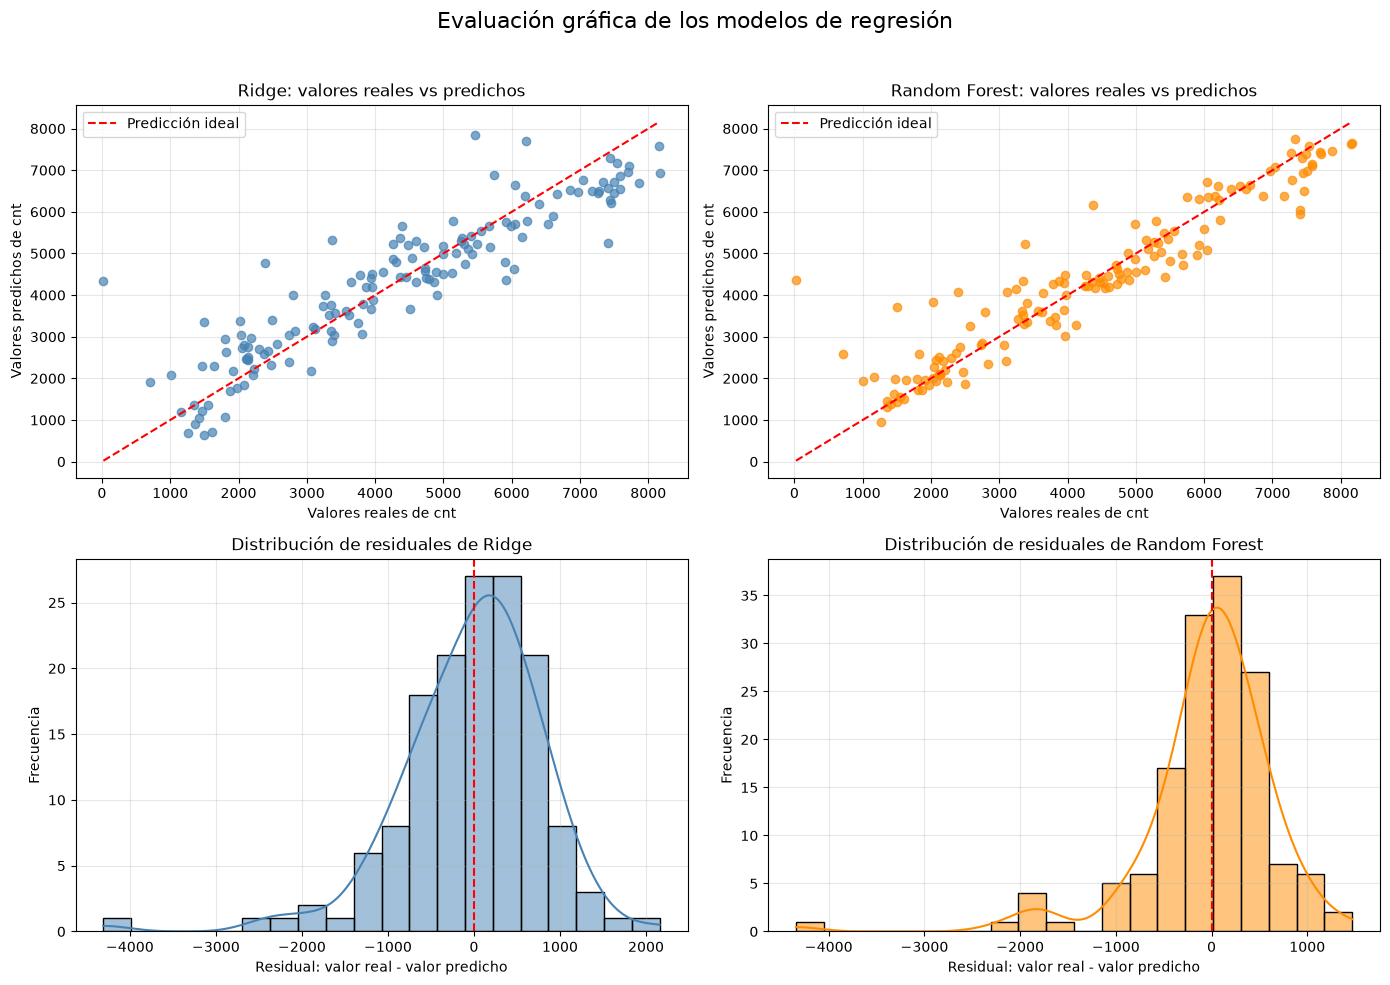

In [73]:
# Calcular los residuales
residuales_ridge = y_test.to_numpy() - pred_ridge_test
residuales_rf = y_test.to_numpy() - pred_rf_test

# Establecer límites comunes para comparar ambos modelos
limite_min = min(
    y_test.min(),
    pred_ridge_test.min(),
    pred_rf_test.min()
)

limite_max = max(
    y_test.max(),
    pred_ridge_test.max(),
    pred_rf_test.max()
)

# Crear una figura con cuatro gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ridge: valores reales frente a predichos
axes[0, 0].scatter(
    y_test,
    pred_ridge_test,
    alpha=0.7,
    color="steelblue"
)

axes[0, 0].plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--",
    color="red",
    label="Predicción ideal"
)

axes[0, 0].set_title("Ridge: valores reales vs predichos")
axes[0, 0].set_xlabel("Valores reales de cnt")
axes[0, 0].set_ylabel("Valores predichos de cnt")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Random Forest: valores reales frente a predichos
axes[0, 1].scatter(
    y_test,
    pred_rf_test,
    alpha=0.7,
    color="darkorange"
)

axes[0, 1].plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--",
    color="red",
    label="Predicción ideal"
)

axes[0, 1].set_title(
    "Random Forest: valores reales vs predichos"
)
axes[0, 1].set_xlabel("Valores reales de cnt")
axes[0, 1].set_ylabel("Valores predichos de cnt")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Ridge: histograma de residuales
sns.histplot(
    residuales_ridge,
    bins=20,
    kde=True,
    color="steelblue",
    ax=axes[1, 0]
)

axes[1, 0].axvline(
    0,
    linestyle="--",
    color="red"
)

axes[1, 0].set_title("Distribución de residuales de Ridge")
axes[1, 0].set_xlabel("Residual: valor real - valor predicho")
axes[1, 0].set_ylabel("Frecuencia")
axes[1, 0].grid(alpha=0.3)

# Random Forest: histograma de residuales
sns.histplot(
    residuales_rf,
    bins=20,
    kde=True,
    color="darkorange",
    ax=axes[1, 1]
)

axes[1, 1].axvline(
    0,
    linestyle="--",
    color="red"
)

axes[1, 1].set_title(
    "Distribución de residuales de Random Forest"
)
axes[1, 1].set_xlabel(
    "Residual: valor real - valor predicho"
)
axes[1, 1].set_ylabel("Frecuencia")
axes[1, 1].grid(alpha=0.3)

# Agregar el título general
fig.suptitle(
    "Evaluación gráfica de los modelos de regresión",
    fontsize=16
)

# Ajustar los espacios entre los gráficos
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Guardar la figura
plt.savefig(
    "figures/predicciones_y_residuales.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Interpretación de los valores predichos y los residuales

En los gráficos de valores reales frente a valores predichos, la línea roja representa una predicción perfecta. Los puntos generados por Random Forest se encuentran, en general, más próximos a esta línea que los correspondientes a Ridge. Esto indica una mayor concordancia entre sus predicciones y la demanda real, lo cual coincide con su menor RMSE y MAE.

Ridge muestra una mayor dispersión y una tendencia a acercar las predicciones hacia valores intermedios. En algunos días de demanda baja realiza sobreestimaciones importantes, mientras que en varios días de demanda alta genera predicciones inferiores al valor real. Este comportamiento indica que el modelo lineal tiene dificultades para representar completamente las relaciones no lineales del problema.

Los residuales de ambos modelos se concentran principalmente alrededor de cero, lo que indica que gran parte de las predicciones presenta errores moderados. Sin embargo, la distribución de Ridge es más amplia, reflejando una mayor variabilidad de los errores. Random Forest presenta una distribución más estrecha y concentrada, consistente con su mejor desempeño general.

En ambos modelos se observa al menos un residual negativo extremo cercano a -4.000. Como el residual fue calculado como valor real menos valor predicho, este resultado corresponde a un día de demanda baja que fue sobreestimado considerablemente. Por tanto, aunque Random Forest presenta el mejor comportamiento global, todavía existen algunas observaciones particulares en las que comete errores elevados.


In [74]:
# Generar predicciones sobre el conjunto de entrenamiento
pred_ridge_train = mejor_ridge.predict(X_train_prep)
pred_rf_train = mejor_rf.predict(X_train_prep)

# Crear una tabla para comparar entrenamiento y prueba
comparacion_ajuste = pd.DataFrame({
    "Modelo": [
        "Ridge",
        "Random Forest"
    ],
    "RMSE train": [
        root_mean_squared_error(
            y_train,
            pred_ridge_train
        ),
        root_mean_squared_error(
            y_train,
            pred_rf_train
        )
    ],
    "RMSE test": [
        root_mean_squared_error(
            y_test,
            pred_ridge_test
        ),
        root_mean_squared_error(
            y_test,
            pred_rf_test
        )
    ],
    "R2 train": [
        r2_score(
            y_train,
            pred_ridge_train
        ),
        r2_score(
            y_train,
            pred_rf_train
        )
    ],
    "R2 test": [
        r2_score(
            y_test,
            pred_ridge_test
        ),
        r2_score(
            y_test,
            pred_rf_test
        )
    ]
})

# Mostrar la comparación con cuatro decimales
comparacion_ajuste.round(4)

,Modelo,RMSE train,RMSE test,R2 train,R2 test
0,Ridge,763.7854,820.0667,0.8409,0.8323
1,Random Forest,312.4867,690.5600,0.9734,0.8811


### Selección y justificación del mejor modelo

Se seleccionó **Random Forest** como el mejor modelo para predecir la demanda diaria de bicicletas. La métrica principal utilizada fue el RMSE, debido a que expresa el error en las mismas unidades de la variable objetivo y penaliza con mayor intensidad las predicciones que presentan errores grandes. En el conjunto de prueba, Random Forest obtuvo un RMSE de 690,5600, inferior al valor de 820,0667 alcanzado por Ridge. También presentó un menor MAE, con 439,0709 arriendos, y un R² superior de 0,8811, lo que indica que explica aproximadamente el 88,11 % de la variabilidad observada en la demanda.

Al comparar entrenamiento y prueba, Random Forest presentó un RMSE de 312,4867 en entrenamiento y de 690,5600 en prueba. Además, su R² disminuyó de 0,9734 a 0,8811. Esta diferencia evidencia cierto grado de sobreajuste, ya que el modelo funciona considerablemente mejor con los datos utilizados para entrenarlo. Ridge mostró un comportamiento más estable, con valores de RMSE de 763,7854 y 820,0667 y valores de R² de 0,8409 y 0,8323 en entrenamiento y prueba, respectivamente. Sin embargo, incluso considerando el sobreajuste, Random Forest mantuvo el mejor desempeño sobre los datos no vistos.

Ridge ofrece una mayor interpretabilidad porque permite examinar directamente sus coeficientes, mientras que Random Forest representa relaciones no lineales y requiere utilizar la importancia de variables para explicar sus predicciones. Random Forest también presentó mayores tiempos de entrenamiento e inferencia, pero ambos continuaron siendo reducidos para el tamaño del dataset. Por estas razones, se seleccionó Random Forest, reconociendo que su mejor capacidad predictiva se obtiene a cambio de una menor interpretabilidad y de cierto sobreajuste.


Cinco variables más importantes:


,Variable,Importancia
0,temp,0.3559
1,atemp,0.1531
8,yr_0,0.1510
9,yr_1,0.1322
2,hum,0.0566


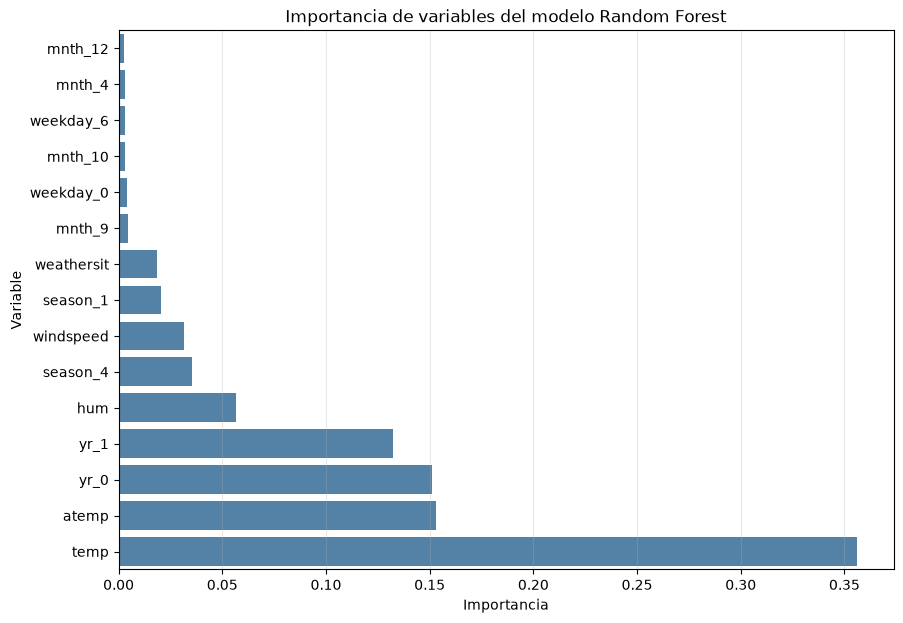

In [75]:
# Crear una tabla con la importancia de todas las variables
importancias_rf = pd.DataFrame({
    "Variable": X_train_prep.columns,
    "Importancia": mejor_rf.feature_importances_
})

# Ordenar desde la variable más importante
importancias_rf = importancias_rf.sort_values(
    by="Importancia",
    ascending=False
)

# Mostrar las cinco variables más importantes
top5_importancias_rf = importancias_rf.head(5)

print("Cinco variables más importantes:")
display(top5_importancias_rf.round(4))

# Seleccionar las 15 variables más importantes para el gráfico
importancias_grafico = (
    importancias_rf
    .head(15)
    .sort_values(by="Importancia", ascending=True)
)

# Crear el gráfico
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importancias_grafico,
    x="Importancia",
    y="Variable",
    color="steelblue"
)

plt.title(
    "Importancia de variables del modelo Random Forest"
)
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.grid(axis="x", alpha=0.3)

# Guardar la figura
plt.savefig(
    "figures/importancia_variables_random_forest.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Interpretación de la importancia de variables

La variable con mayor importancia para Random Forest fue `temp`, con un valor de 0,3559. Esto indica que la temperatura fue la característica más utilizada por el modelo para diferenciar días con distintos niveles de demanda. `atemp`, que representa la sensación térmica, ocupó el segundo lugar con una importancia de 0,1531. Desde una perspectiva de negocio, ambas variables muestran que las condiciones térmicas son determinantes para anticipar la cantidad diaria de bicicletas requeridas.

Las variables `yr_0` y `yr_1` corresponden a las dos categorías creadas por OneHotEncoder a partir de la variable original `yr`. Sus importancias fueron 0,1510 y 0,1322, respectivamente. Consideradas conjuntamente, confirman que el año de observación es relevante para el modelo. La correlación positiva encontrada entre `yr` y `cnt` durante el EDA sugiere que la demanda fue mayor durante el segundo año del dataset.

La quinta variable fue `hum`, con una importancia de 0,0566. Aunque su correlación lineal con `cnt` fue débil y negativa, Random Forest puede detectar relaciones no lineales e interacciones con la temperatura y las condiciones meteorológicas. Por ello, una variable puede resultar útil para el modelo aunque su correlación individual sea baja.

Los resultados coinciden parcialmente con el análisis exploratorio. `temp`, `atemp` y `yr` también estuvieron entre las variables más correlacionadas con `cnt`. En cambio, `season` y `weathersit`, que aparecieron entre las cinco correlaciones más altas, tuvieron menor importancia en Random Forest, mientras que `hum` adquirió mayor relevancia. También debe considerarse que `temp` y `atemp` presentan una correlación de 0,9917 entre sí, por lo que comparten información y su importancia puede distribuirse entre ambas.

Finalmente, la importancia indica cuánto contribuye una variable a las decisiones de los árboles, pero no muestra si su efecto aumenta o disminuye la demanda. Para conocer la dirección de la relación se deben considerar conjuntamente las correlaciones y los gráficos realizados durante el EDA.


In [76]:
# Crear una tabla con las observaciones del conjunto de prueba
errores_rf = X_test.copy()

# Incorporar la fecha original
errores_rf.insert(
    0,
    "dteday",
    df.loc[X_test.index, "dteday"]
)

# Incorporar valores reales y predichos
errores_rf["cnt_real"] = y_test
errores_rf["cnt_predicho"] = pred_rf_test

# Calcular el residual
errores_rf["residual"] = (
    errores_rf["cnt_real"]
    - errores_rf["cnt_predicho"]
)

# Calcular el error absoluto
errores_rf["error_absoluto"] = (
    errores_rf["residual"].abs()
)

# Seleccionar las diez observaciones con mayor error
top10_errores_rf = errores_rf.nlargest(
    10,
    "error_absoluto"
)

# Mostrar las observaciones
top10_errores_rf.round(4)

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt_real,cnt_predicho,residual,error_absoluto
667,2012-10-29,4,1,10,0,1,1,3,0.4400,0.4394,0.8800,0.3582,22,4364.2023,-4342.2023,4342.2023
327,2011-11-24,4,0,11,1,4,0,1,0.3733,0.3725,0.5492,0.1673,1495,3719.4478,-2224.4478,2224.4478
340,2011-12-07,4,0,12,0,3,1,3,0.4100,0.4002,0.9704,0.2662,705,2587.1105,-1882.1105,1882.1105
448,2012-03-24,2,1,3,0,6,0,2,0.5025,0.4867,0.8854,0.1928,3372,5228.3808,-1856.3808,1856.3808
473,2012-04-18,2,1,4,0,3,1,2,0.4633,0.4570,0.5692,0.1679,4367,6175.5521,-1808.5521,1808.5521
101,2011-04-12,2,0,4,0,2,1,2,0.5025,0.4931,0.7392,0.2749,2034,3823.7384,-1789.7384,1789.7384
265,2011-09-23,4,0,9,0,5,1,2,0.6092,0.5221,0.9725,0.0784,2395,4081.0782,-1686.0782,1686.0782
568,2012-07-22,3,1,7,0,0,0,2,0.6675,0.6231,0.7625,0.0939,7410,5940.6395,1469.3605,1469.3605
550,2012-07-04,3,1,7,1,3,0,1,0.7892,0.7323,0.5387,0.1349,7403,6054.1763,1348.8237,1348.8237
266,2011-09-24,4,0,9,0,6,0,2,0.6067,0.5644,0.8625,0.0784,5423,4425.2169,997.7831,997.7831


### Análisis de las observaciones con mayor error

Entre las diez observaciones con mayor error absoluto, siete fueron sobreestimadas por Random Forest. Esto significa que, en la mayoría de los casos extremos, el modelo predijo una demanda superior a la que realmente ocurrió. Las otras tres observaciones fueron subestimadas y corresponden a días en que la demanda real fue considerablemente alta.

El mayor error ocurrió el 29 de octubre de 2012. La demanda real fue de solo 22 arriendos, mientras que el modelo predijo aproximadamente 4.364, generando un residual de -4.342. Este día presentó una condición meteorológica de categoría 3, humedad de 0,8800 y una velocidad del viento relativamente elevada de 0,3582. Esta combinación sugiere condiciones especialmente desfavorables que redujeron la demanda mucho más de lo anticipado por el modelo.

Se observa que ocho de las diez observaciones presentaron condiciones meteorológicas de categoría 2 o 3. Además, siete registraron valores de humedad superiores a 0,70. Por lo tanto, una característica frecuente entre los errores más elevados es la presencia de humedad alta y condiciones meteorológicas menos favorables.

También se aprecia una tendencia del modelo a aproximar las predicciones hacia valores intermedios: sobreestima algunos días con demanda excepcionalmente baja y subestima días con demanda muy alta. Esto puede ocurrir porque Random Forest aprende patrones frecuentes del conjunto de entrenamiento, pero tiene mayores dificultades para predecir acontecimientos poco habituales.

Aunque el modelo incorpora variables meteorológicas, estacionales y de calendario, no dispone de información sobre eventos extraordinarios, interrupciones del servicio u otras circunstancias específicas de cada fecha. Estas variables no observadas podrían explicar por qué días aparentemente similares presentan demandas reales muy diferentes.


## Conclusiones ejecutivas

El análisis del dataset Bike Sharing permitió identificar factores meteorológicos, temporales y estacionales relacionados con la demanda diaria de bicicletas. El conjunto contiene 731 observaciones y 16 variables, sin valores faltantes. Se identificaron dos valores extremos en `hum` (humedad normalizada) y trece en `windspeed` (velocidad del viento normalizada); sin embargo, se mantuvieron porque representan condiciones meteorológicas plausibles y corresponden a una proporción pequeña de los datos. La variable objetivo `cnt` (cantidad total diaria de arriendos de bicicletas) presentó una distribución prácticamente simétrica, con una asimetría de -0,0474, por lo que no fue necesario aplicar una transformación logarítmica.

Durante el análisis exploratorio, las variables con mayor correlación absoluta con la demanda fueron `atemp` (sensación térmica normalizada), con 0,6311; `temp` (temperatura normalizada), con 0,6275; `yr` (año de observación: 0 para 2011 y 1 para 2012), con 0,5667; `season` (estación del año), con 0,4061; y `weathersit` (condición meteorológica), con -0,2974. También se detectó una correlación de 0,9917 entre `temp` (temperatura normalizada) y `atemp` (sensación térmica normalizada), indicando multicolinealidad. Los gráficos mostraron que la demanda tiende a aumentar en condiciones térmicas favorables y a disminuir cuando empeora la condición meteorológica.

En el análisis no supervisado, ocho componentes principales conservaron el 80,62 % de la varianza. K-Means seleccionó dos clusters, aunque el Silhouette Score de 0,2498 indicó una separación moderada a baja. El cluster 0 reunió 301 días más cálidos y alcanzó una demanda promedio aproximada de 5.603 arriendos diarios. El cluster 1 agrupó 283 días más fríos y presentó una demanda promedio cercana a 3.453. Por lo tanto, los clusters representan perfiles generales de demanda alta y baja asociados principalmente con las condiciones térmicas.

Random Forest fue seleccionado como el mejor modelo supervisado. En prueba obtuvo un RMSE de 690,5600, un MAE de 439,0709 y un R² de 0,8811, superando a Ridge. No obstante, la diferencia entre su RMSE de entrenamiento (312,4867) y prueba evidencia cierto sobreajuste. Sus tres variables originales más relevantes fueron `temp` (temperatura normalizada), `atemp` (sensación térmica normalizada) y `yr` (año de observación). En términos de negocio, la temperatura y la sensación térmica permiten anticipar condiciones favorables para el uso de bicicletas, mientras que el año refleja cambios temporales en el nivel general de demanda.

### Limitaciones

1. El dataset contiene solamente 731 días correspondientes a dos años, lo que limita la capacidad para representar cambios de largo plazo.
2. Random Forest presentó cierto sobreajuste, por lo que su desempeño podría disminuir al aplicarse a periodos futuros con patrones diferentes.
3. No se incluyeron eventos extraordinarios, interrupciones del servicio ni actividades masivas. Esta ausencia puede explicar algunos errores extremos.
4. La división aleatoria entre entrenamiento y prueba no reproduce completamente una situación real de predicción futura.
5. El MAPE fue elevado y poco estable debido a la existencia de días con valores reales de demanda muy bajos.

### Recomendaciones

1. Utilizar las predicciones junto con los pronósticos meteorológicos para anticipar la disponibilidad y redistribución de bicicletas, especialmente durante días cálidos y de condiciones favorables.
2. Mantener precaución frente a días con `hum` (humedad normalizada) elevada o `weathersit` (condición meteorológica) adversa, ya que estas características estuvieron presentes en varios de los errores más grandes del modelo.
3. Monitorear periódicamente las métricas e incorporar nuevos datos para evitar que el modelo pierda capacidad predictiva cuando cambien los patrones de uso.

Como trabajo futuro, se propone incorporar información sobre eventos especiales, precipitaciones, interrupciones del servicio y datos meteorológicos más detallados. También sería conveniente utilizar una separación temporal, entrenando con fechas anteriores y evaluando con fechas posteriores, y comparar Random Forest con modelos como Gradient Boosting o métodos específicos para series temporales. Esto permitiría obtener una evaluación más cercana al uso operativo real y buscar una reducción del sobreajuste.
